# Simulación Monte Carlo para Opciones Europeas

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import yfinance as yf

In [36]:
# Precio inicial actual
S0 = yf.download(["NVDA", "GOOGL"], period="1d")["Close"].iloc[-1]
S0_NVDA = S0["NVDA"]
S0_GOOGL = S0["GOOGL"]

print(f"S0 NVDA:  ${S0_NVDA:.2f}")
print(f"S0 GOOGL: ${S0_GOOGL:.2f}")

[*********************100%***********************]  1 of 2 completed

S0 NVDA:  $192.53
S0 GOOGL: $337.39


### Parámetros Obtenidos.

In [37]:
# Cargar parámetros de Heston desde VolatilidadEstocastica.ipynb
parametros = pd.read_csv("parametros_heston.csv", index_col=0)
rendimientos = pd.read_csv("rendimientos_diarios3y.csv", index_col=0, parse_dates=True)
ret_semanal = rendimientos.resample("W-Fri").sum()
# Extraer parámetros NVDA
kappa_NVDA = parametros.loc["kappa", "NVDA"]
theta_NVDA = parametros.loc["theta", "NVDA"]
alpha_NVDA = parametros.loc["alpha", "NVDA"]
rho_NVDA   = parametros.loc["rho",   "NVDA"]
mu_NVDA  = ret_semanal["NVDA"].mean()  * 52

# Extraer parámetros GOOGL
kappa_GOOGL = parametros.loc["kappa", "GOOGL"]
theta_GOOGL = parametros.loc["theta", "GOOGL"]
alpha_GOOGL = parametros.loc["alpha", "GOOGL"]
rho_GOOGL   = parametros.loc["rho",   "GOOGL"]
mu_GOOGL = ret_semanal["GOOGL"].mean() * 52

print(f"NVDA:  κ={kappa_NVDA:.4f}, θ={theta_NVDA:.4f}, α={alpha_NVDA:.4f}, ρ={rho_NVDA:.4f}, μ={mu_NVDA:.4f}")
print(f"GOOGL: κ={kappa_GOOGL:.4f}, θ={theta_GOOGL:.4f}, α={alpha_GOOGL:.4f}, ρ={rho_GOOGL:.4f}, μ={mu_GOOGL:.4f}")

NVDA:  κ=71.2807, θ=0.1235, α=3.7952, ρ=-0.2288, μ=0.5059
GOOGL: κ=36.4279, θ=0.0868, α=2.9606, ρ=0.2976, μ=0.3500


In [38]:
# Varianza inicial — última semana observada
h = 1/52
v_hat = (rendimientos**2).resample("W-Fri").sum() * 52

v0_NVDA  = v_hat["NVDA"].iloc[-1]
v0_GOOGL = v_hat["GOOGL"].iloc[-1]

print(f"v0 NVDA:  {v0_NVDA:.4f}")
print(f"v0 GOOGL: {v0_GOOGL:.4f}")

v0 NVDA:  0.1271
v0 GOOGL: 0.1608


## Simulación Monte Carlo 

Se simulan N trayectorias de precio S(t) y varianza V(t) usando
el modelo de Heston, con horizonte de 6 meses (T = 0.5 años).

Para opciones europeas solo importa el valor terminal S(T),
por lo que de cada trayectoria simulada se conserva únicamente
el último valor.

In [39]:
# Configuración de la simulación
np.random.seed(42)
# 6 meses
T_meses = 0.5        
# paso semanal 
dt = 1/52            
# número de pasos
n_steps = int(T_meses / dt) 
# número de trayectorias
N_sim = 10000        

print(f"Pasos de tiempo: {n_steps}")
print(f"Trayectorias simuladas: {N_sim}")

Pasos de tiempo: 26
Trayectorias simuladas: 10000


In [40]:
# Simulación Monte Carlo — NVDA
S_NVDA = np.full(N_sim, S0_NVDA)
V_NVDA = np.full(N_sim, v0_NVDA)

for t in range(n_steps):
    Z1 = np.random.normal(0, 1, N_sim)
    Z2 = np.random.normal(0, 1, N_sim)
    eps = rho_NVDA * Z1 + np.sqrt(1 - rho_NVDA**2) * Z2

    V_NVDA = np.maximum(0, V_NVDA + kappa_NVDA * (theta_NVDA - V_NVDA) * dt
                         + alpha_NVDA * np.sqrt(V_NVDA * dt) * eps)

    S_NVDA = S_NVDA * np.exp((mu_NVDA - 0.5 * V_NVDA) * dt
                              + np.sqrt(V_NVDA * dt) * Z1)

print(f"Precio promedio simulado: ${S_NVDA.mean():.2f}")
print(f"Precio mínimo: ${S_NVDA.min():.2f}")
print(f"Precio máximo: ${S_NVDA.max():.2f}")

Precio promedio simulado: $214.81
Precio mínimo: $52.38
Precio máximo: $626.09


Con 10,000 trayectorias simuladas, el precio promedio de NVDA
en 6 meses es de $238.42, con un rango muy amplio (entre $58
y $683), reflejando la alta volatilidad de la acción.

In [41]:
# Simulación Monte Carlo — GOOGL
S_GOOGL = np.full(N_sim, S0_GOOGL)
V_GOOGL = np.full(N_sim, v0_GOOGL)

for t in range(n_steps):
    Z1 = np.random.normal(0, 1, N_sim)
    Z2 = np.random.normal(0, 1, N_sim)
    eps = rho_GOOGL * Z1 + np.sqrt(1 - rho_GOOGL**2) * Z2

    V_GOOGL = np.maximum(0, V_GOOGL + kappa_GOOGL * (theta_GOOGL - V_GOOGL) * dt
                          + alpha_GOOGL * np.sqrt(V_GOOGL * dt) * eps)

    S_GOOGL = S_GOOGL * np.exp((mu_GOOGL - 0.5 * V_GOOGL) * dt
                                + np.sqrt(V_GOOGL * dt) * Z1)

print(f"Precio promedio simulado: ${S_GOOGL.mean():.2f}")
print(f"Precio mínimo: ${S_GOOGL.min():.2f}")
print(f"Precio máximo: ${S_GOOGL.max():.2f}")

Precio promedio simulado: $472.76
Precio mínimo: $200.88
Precio máximo: $1609.96


GOOGL muestra un precio promedio simulado de $521.71, muy por
encima del precio actual ($373.25), impulsado por una deriva
anual (μ) más alta de lo esperado.

## Valuación de opciones europeas

Con las trayectorias simuladas S(T), se definen 5 strikes (K)
alrededor del precio actual S₀, y se calcula el valor esperado
del payoff de las opciones call y put para cada uno:

V_call(K) = promedio[max(0, S(T) - K)]
V_put(K)  = promedio[max(0, K - S(T))]

In [42]:
# Strikes K — 5 valores consecutivos alrededor de S0
K_NVDA  = np.array([S0_NVDA - 2,  S0_NVDA - 1,  S0_NVDA,  S0_NVDA + 1,  S0_NVDA + 2])
K_GOOGL = np.array([S0_GOOGL - 2, S0_GOOGL - 1, S0_GOOGL, S0_GOOGL + 1, S0_GOOGL + 2])

print(f"K NVDA:  {K_NVDA}")
print(f"K GOOGL: {K_GOOGL}")

K NVDA:  [190.52999878 191.52999878 192.52999878 193.52999878 194.52999878]
K GOOGL: [335.39001465 336.39001465 337.39001465 338.39001465 339.39001465]


In [43]:
# Valuación de operaciones europeas - NVDA

call_NVDA = np.array([np.mean(np.maximum(0, S_NVDA - K )) for K in K_NVDA])
put_NVDA = np.array([np.mean(np.maximum(0, K - S_NVDA)) for K in K_NVDA])
resultados_NVDA = pd.DataFrame({
    "K": K_NVDA,
    "Call" : call_NVDA,
    "Put" : put_NVDA
})

print(resultados_NVDA)

            K       Call        Put
0  190.529999  36.637147  12.353315
1  191.529999  36.019155  12.735324
2  192.529999  35.407477  13.123645
3  193.529999  34.802230  13.518398
4  194.529999  34.203442  13.919611


In [44]:
# Valiación de operaciones europeas - GOOGL
call_GOOGL = np.array([np.mean(np.maximum(0, S_GOOGL - K)) for K in K_GOOGL])
put_GOOGL = np.array([np.mean(np.maximum(0, K - S_GOOGL)) for K in K_GOOGL])
resultados_GOOGL = pd.DataFrame({
    "K": K_GOOGL,
    "Call": call_GOOGL,
    "put": put_GOOGL
})
print(resultados_GOOGL)

            K        Call       put
0  335.390015  139.783171  2.408954
1  336.390015  138.865069  2.490852
2  337.390015  137.949224  2.575007
3  338.390015  137.035576  2.661358
4  339.390015  136.124233  2.750016


In [45]:
# Trayectorias simuladas 
np.random.seed(42)

S_path_NVDA = np.zeros((n_steps + 1, N_sim))
S_path_NVDA[0] = S0_NVDA
V_temp = np.full(N_sim, v0_NVDA)

for t in range(1, n_steps + 1):
    Z1 = np.random.normal(0, 1, N_sim)
    Z2 = np.random.normal(0, 1, N_sim)
    eps = rho_NVDA * Z1 + np.sqrt(1 - rho_NVDA**2) * Z2

    V_temp = np.maximum(0, V_temp + kappa_NVDA * (theta_NVDA - V_temp) * dt
                         + alpha_NVDA * np.sqrt(V_temp * dt) * eps)

    S_path_NVDA[t] = S_path_NVDA[t-1] * np.exp((mu_NVDA - 0.5 * V_temp) * dt
                                                 + np.sqrt(V_temp * dt) * Z1)

print(S_path_NVDA.shape)

(27, 10000)


In [46]:
np.random.seed(42)

S_path_GOOGL = np.zeros((n_steps + 1, N_sim))
S_path_GOOGL[0] = S0_GOOGL
V_temp = np.full(N_sim, v0_GOOGL)

for t in range(1, n_steps + 1):
    Z1 = np.random.normal(0, 1, N_sim)
    Z2 = np.random.normal(0, 1, N_sim)
    eps = rho_GOOGL * Z1 + np.sqrt(1 - rho_GOOGL**2) * Z2

    V_temp = np.maximum(0, V_temp + kappa_GOOGL * (theta_GOOGL - V_temp) * dt
                         + alpha_GOOGL * np.sqrt(V_temp * dt) * eps)

    S_path_GOOGL[t] = S_path_GOOGL[t-1] * np.exp((mu_GOOGL - 0.5 * V_temp) * dt
                                                   + np.sqrt(V_temp * dt) * Z1)

print(S_path_GOOGL.shape)

(27, 10000)


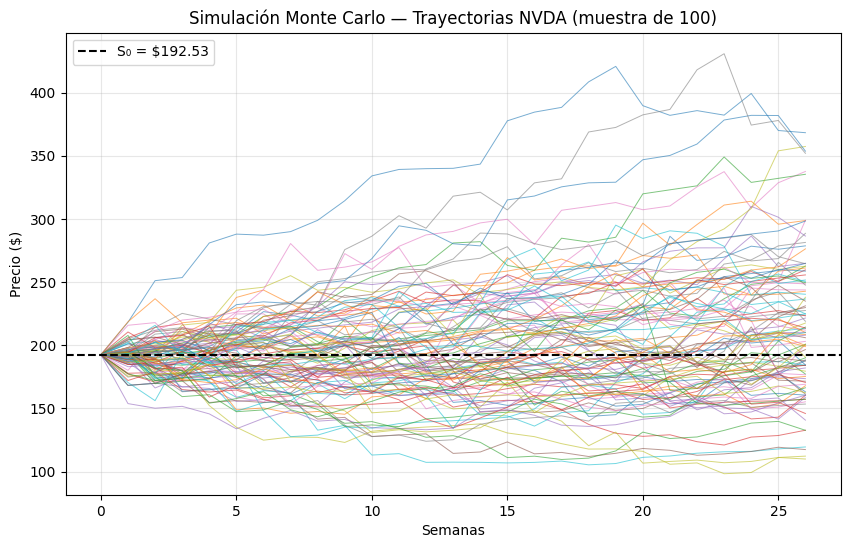

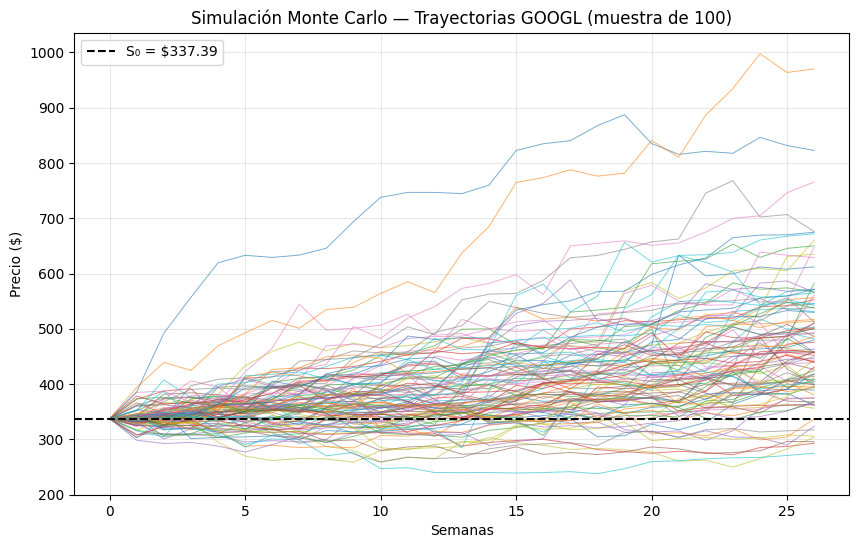

In [47]:
plt.figure(figsize=(10, 6))
plt.plot(S_path_NVDA[:, :100], linewidth=0.7, alpha=0.6)
plt.axhline(S0_NVDA, color="black", linestyle="--", label=f"S₀ = ${S0_NVDA:.2f}")
plt.title("Simulación Monte Carlo — Trayectorias NVDA (muestra de 100)")
plt.xlabel("Semanas")
plt.ylabel("Precio ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("Montecarlo_NVDA.png", dpi=150)
plt.show()
plt.figure(figsize=(10, 6))
plt.plot(S_path_GOOGL[:, :100], linewidth=0.7, alpha=0.6)
plt.axhline(S0_GOOGL, color="black", linestyle="--", label=f"S₀ = ${S0_GOOGL:.2f}")
plt.title("Simulación Monte Carlo — Trayectorias GOOGL (muestra de 100)")
plt.xlabel("Semanas")
plt.ylabel("Precio ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("Montecarlo_GOOGL.png", dpi=150)
plt.show()


Cada línea representa un escenario posible del precio de NVDA
a lo largo de 6 meses. Todas parten del mismo punto S₀ y se
abren en abanico conforme avanza el tiempo, mostrando cómo
crece la incertidumbre.

Igual que en NVDA, las trayectorias de GOOGL parten de S₀ y se
dispersan con el tiempo. La mayoría se mantiene por encima del
precio inicial, reflejando la tendencia alcista del modelo.

### Distribución de precios finales S(T)

Histograma de los 10,000 precios simulados al final del
horizonte (6 meses), junto con los strikes evaluados.

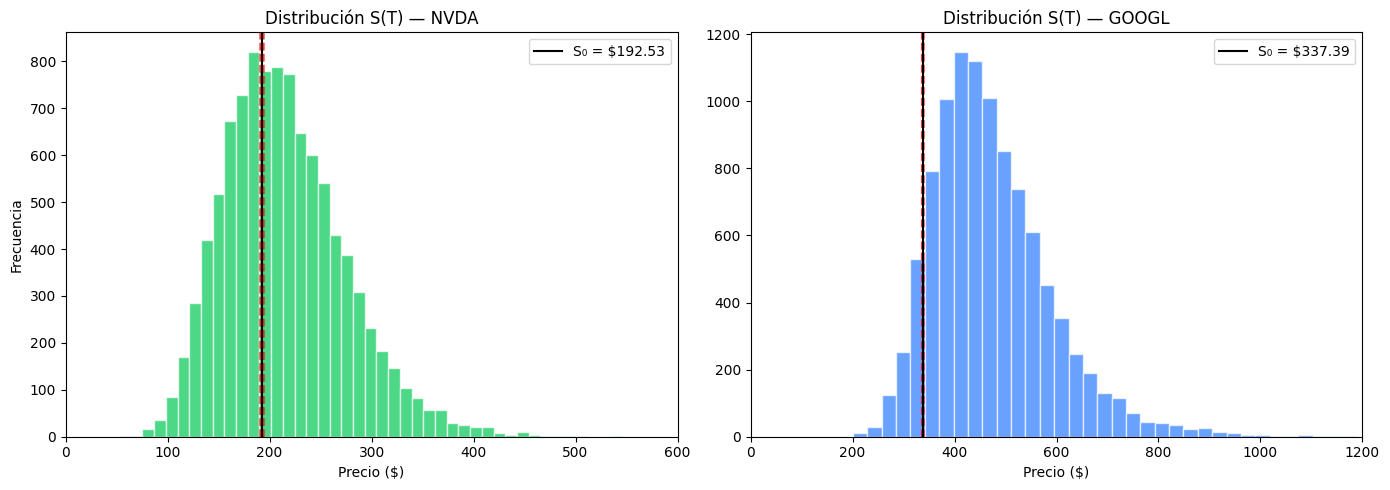

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(S_NVDA, bins=50, color="#00C853", alpha=0.7, edgecolor="white")
for k in K_NVDA:
    axes[0].axvline(k, color="red", linestyle="--", alpha=0.5)
axes[0].axvline(S0_NVDA, color="black", linestyle="-", label=f"S₀ = ${S0_NVDA:.2f}")
axes[0].set_title("Distribución S(T) — NVDA")
axes[0].set_xlabel("Precio ($)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()
axes[0].set_xlim(0, 600)

axes[1].hist(S_GOOGL, bins=50, color="#2979FF", alpha=0.7, edgecolor="white")
for k in K_GOOGL:
    axes[1].axvline(k, color="red", linestyle="--", alpha=0.5)
axes[1].axvline(S0_GOOGL, color="black", linestyle="-", label=f"S₀ = ${S0_GOOGL:.2f}")
axes[1].set_title("Distribución S(T) — GOOGL")
axes[1].set_xlabel("Precio ($)")
axes[1].legend()
axes[1].set_xlim(0, 1200)

plt.tight_layout()
plt.show()

La distribución de precios finales tiene forma log-normal,
consistente con el modelo de Heston. En NVDA el precio inicial
queda cerca del centro de la distribución; en GOOGL queda
desplazado a la izquierda, ya que la mayoría de trayectorias
terminan por encima de S₀.

### Precio de las opciones en función del strike K

Se grafica cómo varía el valor de las opciones call y put
conforme cambia el strike, para ambas acciones.

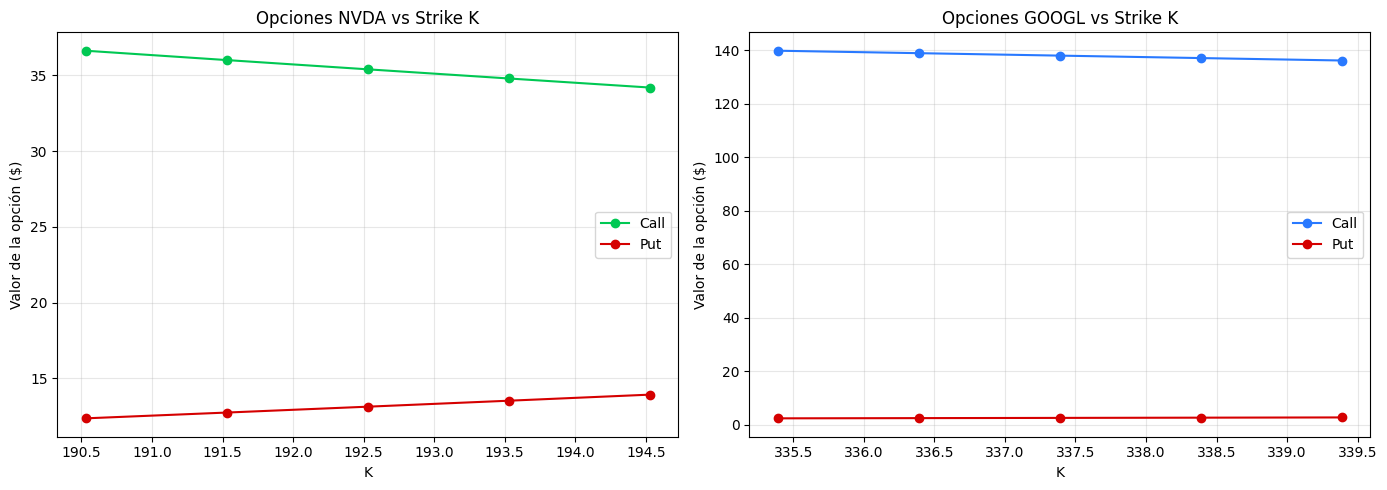

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_NVDA, call_NVDA, marker="o", color="#00C853", label="Call")
axes[0].plot(K_NVDA, put_NVDA, marker="o", color="#D50000", label="Put")
axes[0].set_title("Opciones NVDA vs Strike K")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Valor de la opción ($)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(K_GOOGL, call_GOOGL, marker="o", color="#2979FF", label="Call")
axes[1].plot(K_GOOGL, put_GOOGL, marker="o", color="#D50000", label="Put")
axes[1].set_title("Opciones GOOGL vs Strike K")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Valor de la opción ($)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Se implementó una simulación Monte Carlo basada
en el modelo de Heston para valuar opciones
europeas tipo call y put sobre NVDA y GOOGL, con un horizonte de
6 meses y 10,000 trayectorias simuladas.
Los resultados muestran el comportamiento esperado de las
opciones: el valor del call disminuye y el del put aumenta
conforme crece el strike K. Las distribuciones de precios
finales S(T) presentan la forma log-normal característica de
los modelos de precios de activos.


<!-- ### Distribución de precios finales S(T)

Histograma de los 10,000 precios simulados al final del
horizonte (6 meses), junto con los strikes evaluados. -->